# Task 5: Applying GraphSHAP-IQ to a new dataset

This notebook applies **GraphSHAP-IQ** to **IMDB-BINARY** from TU Dataset, a graph classification dataset that was **not** used in the original GraphSHAP-IQ paper experiments.

**Notebook structure:**
1. Load and preprocess the dataset
2. Exploratory data analysis (features, graph structure)
3. Define three GNN architectures
4. Train models (multi-seed)
5. Compute GraphSHAP-IQ explanations
6. Visualize and analyze interaction patterns

## 0. Setup and imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch.nn import Linear, Sequential, ReLU

import torch_geometric
from torch_geometric.datasets import TUDataset
from torch_geometric.transforms import OneHotDegree
from torch_geometric.loader import DataLoader
from torch_geometric.utils import degree
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool
from torch_geometric.utils import to_networkx

from shapiq.explainer import Explainer
from shapiq.plot import si_graph_plot

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Loading data

IMDB-BINARY comes from the [TU Dortmund graph benchmark collection](https://chrsmrrs.github.io/datasets/docs/datasets/). 
- Each graph repesents an **ego-network of actors**
- Nodes = performers
- edges indicate co-appearance in movies
- Task is **binary graph classification** (two movie-genre groups (romance or action)).

The original dataset does not provide node features. Therefore, we use the node degree as a structural feature and encode it as a one-hot vector (OneHotDegree). This allows the GNN models to distinguish nodes based on their local connectivity patterns. This is a standard baseline feature representation for this dataset.

In [2]:
# Load raw dataset
raw_dataset = TUDataset(root="data/IMDB-BINARY", name="IMDB-BINARY")

# Degree means the number of neighbors a node has. We need to know the maximum degree to create one-hot encoded features of the right size.
max_degree = max(
    int(degree(g.edge_index[0], num_nodes=g.num_nodes).max())
    for g in raw_dataset
)

# Create one-hot degree features
dataset = TUDataset(
    root="data/IMDB-BINARY",
    name="IMDB-BINARY",
    pre_transform=OneHotDegree(max_degree=max_degree),
    force_reload=True,
)

in_channels = dataset.num_node_features
labels = np.array([g.y.item() for g in dataset])

# Dataset overview
classes, counts = np.unique(labels, return_counts=True)
class_info = ", ".join(
    [f"{c}: {int(n)} ({n/len(labels)*100:.1f}%)" for c, n in zip(classes, counts)]
)

overview_df = pd.DataFrame({
    "Metric": [
        "Number of graphs",
        "Number of classes",
        "Class distribution",
        "Maximum node degree",
        "Input feature dimension"
    ],
    "Value": [
        len(dataset),
        dataset.num_classes,
        class_info,
        max_degree,
        in_channels
    ]
})

overview_df

Processing...
Done!
Processing...
Done!


,Metric,Value
0,Number of graphs,1000
1,Number of classes,2
2,Class distribution,"0: 500 (50.0%), 1: 500 (50.0%)"
3,Maximum node degree,135
4,Input feature dimension,136


## 2. Class-wise example graph visualization (Data understanding)
To better understand the structural differences between the two classes in IMDB-BINARY, we visualize a small set of representative graphs from each class.

For each class, we select a few example graphs with relatively small node counts to ensure readability. Each graph is visualized as an ego-network where nodes represent actors and edges indicate co-appearances in movies.

Node size and color encode the node degree, highlighting highly connected actors within each graph. This helps to visually inspect structural patterns that may be relevant for the downstream classification task.

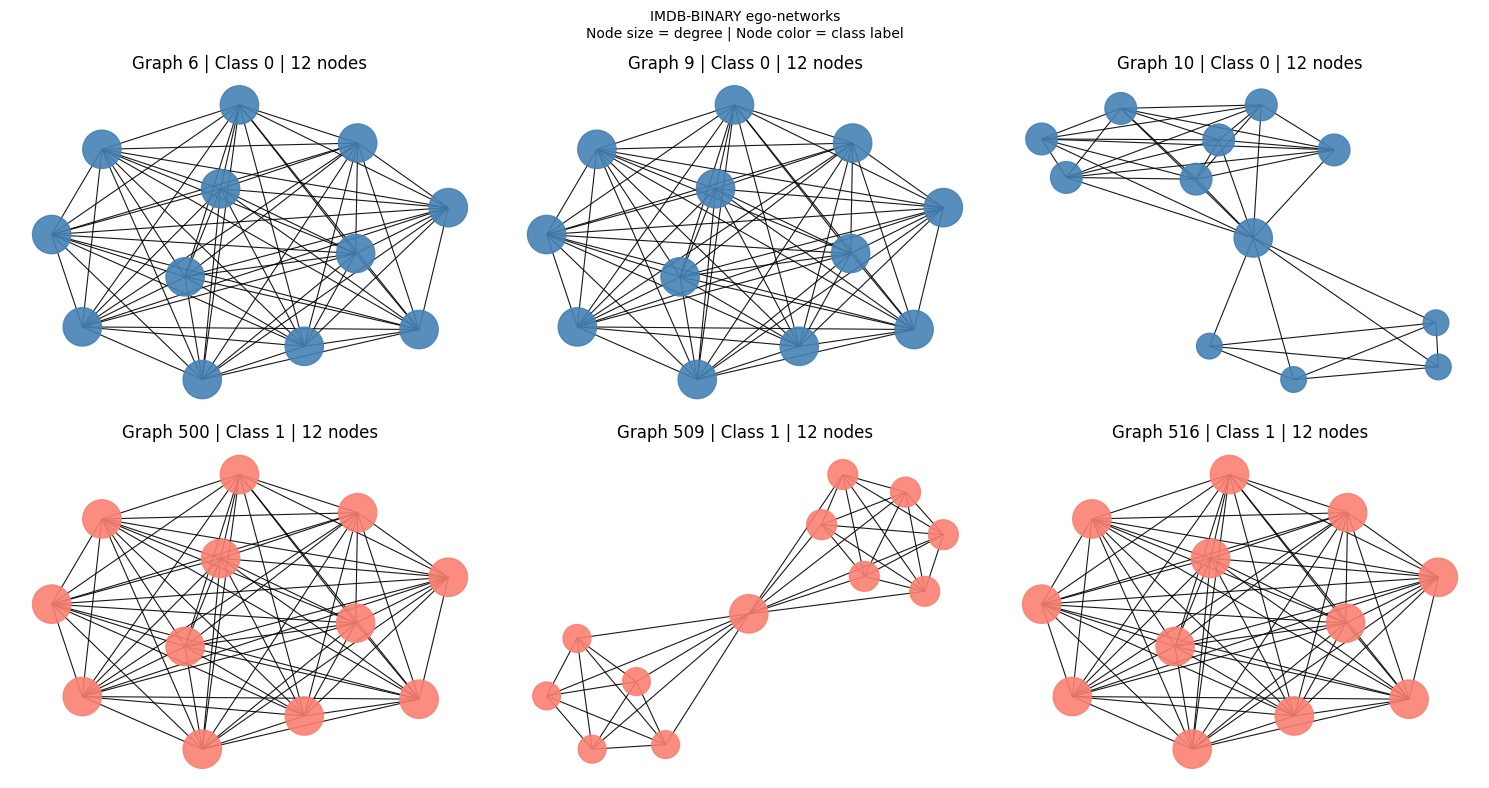

In [3]:
# =========================
# Select representative graphs per class
# =========================

example_indices = []

for c in np.unique(labels):

    # Get all graphs of class c
    class_indices = np.where(labels == c)[0]

    # Sort by graph size (optional but improves readability)
    class_indices = sorted(
        class_indices,
        key=lambda idx: dataset[int(idx)].num_nodes
    )

    # Take 3 representative graphs per class
    example_indices.extend(class_indices[:3])


# =========================
# Plot setup
# =========================

n_cols = 3
n_rows = int(np.ceil(len(example_indices) / n_cols))

CLASS_NAMES = {0: "Class 0", 1: "Class 1"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)


# =========================
# Visualization
# =========================

for i, graph_idx in enumerate(example_indices):

    # Load graph
    g = dataset[int(graph_idx)]
    g_nx = to_networkx(g, to_undirected=True)

    # Layout
    pos = nx.spring_layout(g_nx, seed=SEED)

    # Node degrees (used for size)
    node_degrees = torch_geometric.utils.degree(
        g.edge_index[0],
        num_nodes=g.num_nodes
    ).numpy()

    # Node color = class label
    node_color = (
        "steelblue" if g.y.item() == 0 else "salmon"
    )

    # Draw graph
    nx.draw_networkx(
        g_nx,
        pos=pos,
        ax=axes[i],

        # structure → size
        node_size=100 + 60 * node_degrees,

        # class → color
        node_color=node_color,

        with_labels=False,
        width=0.8,
        alpha=0.9,
    )

    # Title
    axes[i].set_title(
        f"Graph {int(graph_idx)} | {CLASS_NAMES[int(g.y.item())]} | "
        f"{g.num_nodes} nodes"
    )
    axes[i].axis("off")


# =========================
# Remove empty axes
# =========================

for j in range(i + 1, len(axes)):
    axes[j].axis("off")


# =========================
# Global title
# =========================

plt.suptitle(
    "IMDB-BINARY ego-networks\n"
    "Node size = degree | Node color = class label",
    fontsize=10,
)

plt.tight_layout()
plt.show()

## 3. Train / validation / test split

We use a reproducible 70/10/20 split with a fixed random seed.

Since IMDB-BINARY does not provide a predefined split, this random partitioning is a standard evaluation protocol in graph classification benchmarks. The validation set is used for model selection and early stopping, ensuring a fair comparison across different GNN architectures.

In [4]:
from torch.utils.data import random_split

# =========================
# Reproducibility
# =========================

set_seed(SEED)

# Total number of graphs
n_total = len(dataset)

# =========================
# Split sizes (70 / 10 / 20)
# =========================

train_size = int(0.7 * n_total)
val_size = int(0.1 * n_total)
test_size = n_total - train_size - val_size  # ensures no rounding loss

# =========================
# Proper random split (PyTorch standard)
# =========================

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True   # important: stochasticity for training
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False  # deterministic evaluation
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False  # final evaluation must be stable
)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "num_graphs": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ]
})

,split,num_graphs
0,train,700
1,val,100
2,test,200


## 4. Define GNN architectures (GCN, GIN, GAT)

We use three standard message-passing architectures with three layers each and global mean pooling for graph-level readout. All models share the same hidden dimension (64) and output dimension (number of classes).
- GCN: uses a normalized averaging of neighboring node features, making it simple and efficient.
- GIN: applies a learnable multilayer perceptron (MLP) after aggregation, which generally provides higher expressive power for distinguishing graph structures.
- GAT: introduces an attention mechanism that learns different importance weights for neighboring nodes, allowing the model to focus on the most relevant connections during message passing.


In [5]:
# =========================
# Graph-Convolutional Network (GCN) 
# =========================
class GCNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # first graph convolution layer transforms input features to hidden dimension
        self.conv1 = GCNConv(in_channels, hidden_channels)
        
        # second and third graph convolution layers keep the hidden dimension 
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # final linear layer maps from hidden dimension to output dimension (number of classes)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index, edge_weight=None).relu()
        x = self.conv2(x, edge_index, edge_weight=None).relu()
        x = self.conv3(x, edge_index, edge_weight=None).relu()
        
        # global mean pooling aggregates node features into a graph-level representation
        x = global_mean_pool(x, batch)
        return self.lin(x)


# =========================
# Graph Isomorphism Network (GIN) 
# =========================
class GINModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        # MLP for the first GIN-layer
        nn1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(nn1)
        
        # MLP for the second GIN-layer
        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(nn2)
        
        # MLP for the third GIN-layer
        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINConv(nn3)
        
        # final linear layer maps from hidden dimension to output dimension (number of classes)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Neighbor aggregation + MLP
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index).relu()

        # Graph-level representation via global mean pooling
        x = global_mean_pool(x, batch)

        return self.lin(x)


# =========================
# Graph Attention Network (GAT) 
# =========================
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=2):
        super().__init__()
        
        # first graph attention layer
        self.conv1 = GATConv(in_channels, hidden_channels // heads, heads=heads)
        
        # second graph attention layer
        self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads)
        
        # third graph attention layer
        self.conv3 = GATConv(hidden_channels, hidden_channels // heads, heads=heads)
        
        
        # final linear layer maps from hidden dimension to output dimension (number of classes)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        
        # attention-based neighbor aggregation
        x = self.conv1(x, edge_index, edge_attr=None).relu()
        x = self.conv2(x, edge_index, edge_attr=None).relu()
        x = self.conv3(x, edge_index, edge_attr=None).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)

## 5. Train and evaluate models

Each architecture (GCN, GIN, GAT) is trained on the 70% training split with early stopping
based on validation loss. Training is repeated with three random seeds to estimate stability.
The best model per seed (highest validation accuracy) is retained for the final test evaluation
and subsequent GraphSHAP-IQ explanation analysis.

All models share the same hyperparameters.

In [6]:
# ── 5.1 Training helpers ──────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    """One full training pass over the loader. Returns average loss."""
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        # Forward Pass: Modell berechnet Vorhersagen (Logits) für den Batch
        out = model(data.x, data.edge_index, data.batch)
        
        # Loss berechnen: wie weit liegen Vorhersagen von den echten Labels entfernt?
        # criterion = CrossEntropyLoss → misst Abstand zwischen Logits und echten Klassen
        loss = criterion(out, data.y)
        
        # Backward Pass: Gradienten berechnen und Gewichte aktualisieren
        loss.backward()
        optimizer.step()
        # Loss aufaddieren
        total_loss += loss.item() * data.num_graphs
    
    # Durchschnittlicher Loss pro Graph über alle Batches
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    """Compute accuracy and average loss on a loader."""
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    total_loss, correct = 0.0, 0
    for data in loader:
        data = data.to(device)
        
        # Forward Pass: Modell berechnet Vorhersagen (Logits) für den Batch
        out = model(data.x, data.edge_index, data.batch)
        # Loss berechnen: wie weit liegen Vorhersagen von den echten Labels entfernt?
        total_loss += criterion(out, data.y).item() * data.num_graphs
        # Accuracy berechnen: wie viele Vorhersagen stimmen mit den echten Labels überein?
        correct += int((out.argmax(dim=-1) == data.y).sum())
    
    # Gibt zurück:
        # 1. Accuracy = Anteil korrekt klassifizierter Graphen (z.B. 0.795 = 79.5%)
        # 2. Durchschnittlicher Loss pro Graph
    return correct / len(loader.dataset), total_loss / len(loader.dataset)


# ── 5.2 run_experiment: train with val-based early stopping ───────────────────

def run_experiment(model_class, epochs=200, lr=0.005, patience=30, log_every=10):
    """
    Train a model with early stopping on the validation set.

    Args:
        model_class: GCN, GINM, GAT
        epochs:      Maximum number of training epochs
        lr:          Learning rate for Adam
        patience:    Early stopping patience (epochs without val improvement)
        log_every:   Print progress every N epochs

    Returns:
        model:        Best model (loaded from checkpoint)
        best_val_acc: Best validation accuracy achieved
        test_acc:     Test accuracy of the best model
    """
    
    model = model_class(
        in_channels=in_channels,
        hidden_channels=128,
        out_channels=dataset.num_classes,
    ).to(device)

        # Adam-Optimizer: passt Lernraten pro Parameter adaptiv an
    # weight_decay=5e-4 ist L2-Regularisierung → bestraft große Gewichte → weniger Overfitting
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    # CrossEntropyLoss: Standard für Klassifikation
    criterion = torch.nn.CrossEntropyLoss()
    model_name = model_class.__name__

    print(f"\n{'='*60}", flush=True)
    print(f"  {model_name} | epochs={epochs} | lr={lr} | patience={patience}", flush=True)
    print(f"{'='*60}", flush=True)
    print(f"{'Epoch':>6} | {'TrainLoss':>9} | {'TrainAcc':>9} | {'ValAcc':>7} | {'TestAcc':>8}", flush=True)
    print(f"{'-'*60}", flush=True)

       # ── Early-Stopping-Variablen ──────────────────────────────────────────────
    best_val_acc  = 0.0            # beste Val-Accuracy die wir je gesehen haben
    best_val_loss = float("inf")   # bester (niedrigster) Val-Loss — startet bei ∞
    best_state    = None           # Kopie der besten Modellgewichte
    no_improve    = 0              # Zähler: wie viele Epochen ohne Verbesserung?

     # ── Trainingsloop ─────────────────────────────────────────────────────────
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        train_acc, _ = evaluate(model, train_loader)
        val_acc, val_loss = evaluate(model, val_loader)
        test_acc, _ = evaluate(model, test_loader)

        # Save best model by validation accuracy
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(
                f"{epoch:>6} | {train_loss:>9.4f} | {train_acc:>9.4f} | "
                f"{val_acc:>7.4f} | {test_acc:>8.4f}",
                flush=True,
            )

        # Early stopping based on validation loss
        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch} (no val improvement for {patience} epochs)", flush=True)
            break

    # Restore best model weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final evaluation on test set using best model
    final_test_acc, _ = evaluate(model, test_loader)
    print(f"\n→ {model_name} done | best_val_acc={best_val_acc:.4f} | final_test_acc={final_test_acc:.4f}\n", flush=True)

    return model, best_val_acc, final_test_acc


# ── 5.3 Multi-seed training ───────────────────────────────────────────────────

seeds = [42, 123, 999]

# Stores accuracy lists per model across seeds
results = {name: {"val": [], "test": []} for name in ["GCN", "GIN", "GAT"]}

# Stores the last trained model per architecture (used for explanations)
trained_models = {}

print("Starting multi-seed training...\n", flush=True)

for model_name, model_cls in [("GCN", GCNModel), ("GIN", GINModel), ("GAT", GATModel)]:
    for seed in seeds:
        print(f"--- {model_name} | Seed {seed} ---", flush=True)
        set_seed(seed)
        model, val_acc, test_acc = run_experiment(model_cls)
        results[model_name]["val"].append(val_acc)
        results[model_name]["test"].append(test_acc)
        trained_models[model_name] = model  # keep last seed's model for explanations


# ── 5.4 Summary table ─────────────────────────────────────────────────────────

summary_rows = []
for name in ["GCN", "GIN", "GAT"]:
    val_scores = results[name]["val"]
    test_scores = results[name]["test"]
    summary_rows.append({
        "Model": name,
        "Val Acc (mean ± std)": f"{np.mean(val_scores):.3f} ± {np.std(val_scores):.3f}",
        "Test Acc (mean ± std)": f"{np.mean(test_scores):.3f} ± {np.std(test_scores):.3f}",
        "Best Test Acc": f"{max(test_scores):.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== Multi-Seed Training Summary ===")
display(summary_df)

Starting multi-seed training...

--- GCN | Seed 42 ---

  GCNModel | epochs=200 | lr=0.005 | patience=30
 Epoch | TrainLoss |  TrainAcc |  ValAcc |  TestAcc
------------------------------------------------------------
     1 |    0.6445 |    0.7129 |  0.7700 |   0.7950
    10 |    0.5076 |    0.7443 |  0.8100 |   0.8150
    20 |    0.4756 |    0.7600 |  0.7700 |   0.8000
    30 |    0.4544 |    0.7743 |  0.7800 |   0.8100
    40 |    0.4353 |    0.7786 |  0.7400 |   0.8100
    50 |    0.4229 |    0.7914 |  0.7600 |   0.8000
  Early stopping at epoch 54 (no val improvement for 30 epochs)

→ GCNModel done | best_val_acc=0.7800 | final_test_acc=0.8250

--- GCN | Seed 123 ---

  GCNModel | epochs=200 | lr=0.005 | patience=30
 Epoch | TrainLoss |  TrainAcc |  ValAcc |  TestAcc
------------------------------------------------------------
     1 |    0.6281 |    0.6929 |  0.8200 |   0.7150
    10 |    0.5008 |    0.7500 |  0.7800 |   0.7950
    20 |    0.4811 |    0.7500 |  0.8000 |   0.8050


,Model,Val Acc (mean ± std),Test Acc (mean ± std),Best Test Acc
0,GCN,0.783 ± 0.012,0.795 ± 0.022,0.825
1,GIN,0.833 ± 0.005,0.758 ± 0.012,0.775
2,GAT,0.787 ± 0.019,0.785 ± 0.007,0.795


## 6. GraphSHAP-IQ Explanations

TODO

In [7]:
from shapiq.graph import GraphExplainer, GraphSHAPIQ
from collections import Counter
import torch
import pandas as pd
from IPython.display import display


# 
GRAPHS_PER_CLASS = 1

@torch.no_grad()
def get_graphwise_predictions(model, dataset):
    """
    Performs inference on all graphs in the dataset and returns a summary DataFrame.
    
    Args:
        model: The trained Graph Neural Network.
        dataset: A collection of graphs (e.g., PyG dataset).
        
    Returns:
        pd.DataFrame: A table containing graph indices, labels, and performance metrics.
    """
    model.eval()
    rows = []

    for idx in range(len(dataset)):
        graph = dataset[idx].to(device)
        batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=device)
        logits = model(graph.x, graph.edge_index, batch)
        pred = int(logits.argmax(dim=1).item()) # Predicted class (0 or 1)
        true = int(graph.y.item()) # True class of the graph
        rows.append({
            "graph_idx": idx,
            "true_label": true,
            "pred_label": pred,
            "correct": pred == true, # Compare predicted and true labels for correctness
            "num_nodes": int(graph.num_nodes),
            "num_edges": int(graph.edge_index.size(1)),
        })
    return pd.DataFrame(rows)

# ── Evaluate model performance on the test set ───────────────────────────────
graphwise_eval = {}
for model_name, model in trained_models.items():
    graphwise_eval[model_name] = get_graphwise_predictions(model, test_dataset)
    acc = graphwise_eval[model_name]["correct"].mean()
    print(f"{model_name}: test accuracy = {acc:.3f}", flush=True)


# Selection of exactly 6 pairs
selected_graph_ids = {}

for model_name, eval_df in graphwise_eval.items():
    # Calculate completeness
    eval_df["max_edges"] = eval_df["num_nodes"] * (eval_df["num_nodes"] - 1) // 2
    eval_df["is_complete"] = eval_df["num_edges"] // 2 == eval_df["max_edges"]

    # Filter-logic:
    # CHoose only graphs that
    # a) are correctly classified by the model
    # b) are not complete graphs (we want some structure to explain)
    valid_graphs = eval_df[eval_df["correct"] & ~eval_df["is_complete"]]

    # Sorting;
    # Sort by amount of nodes to prioritize simpler graphs for better visualization and due to computational constraints
    
    # First 6 graphs by node size for class 0
    c0_graphs = valid_graphs[valid_graphs["true_label"] == 0].sort_values("num_nodes").head(GRAPHS_PER_CLASS)
    # First 6 graphs by node size for class 1
    c1_graphs = valid_graphs[valid_graphs["true_label"] == 1].sort_values("num_nodes").head(GRAPHS_PER_CLASS)
    # Cobine both class lists and drop duplicates (in case some graphs are in both classes, which is unlikely but we want to be sure)
    chosen_df = pd.concat([c0_graphs, c1_graphs]).drop_duplicates(subset=["graph_idx"])
    # Store selected graph indices for this model
    selected_graph_ids[model_name] = chosen_df["graph_idx"].tolist()

        
# ── 6.2 Explanation helpers ───────────────────────────────────────────────────

def explain_graph(model, graph, model_name, l_shapley_max_budget=500_000_000):
    """Berechnet die GraphSHAP-IQ Interaktionswerte."""
    model.eval()

    if not hasattr(model, "num_layers"):
        model.num_layers = 3

    # Initialize GraphExplainer
        # We use "k-SII" as the index to compute Shapley Interaction Indices up to order 2.
    explainer = GraphExplainer(
        model=model,
        index="k-SII",
        max_order=2,
        baseline_strategy="zeros",
        normalize=False,
        l_shapley_max_budget=l_shapley_max_budget,
    )

    from shapiq_games.benchmark.graphshapiq_xai.base import GraphGame as BenchmarkGraphGame
    
    # Definition of the game: model is considered as game, where nodes are players
    game = BenchmarkGraphGame(
        model=model,
        x_graph=graph,
        baseline_strategy="zeros",
        normalize=False,
        verbose=False,
    )
    graphshapiq = GraphSHAPIQ(game=game, verbose=False)
    budget = graphshapiq.total_budget # How many combinations would need to be computed exactly?

    # Efficiency-decision: Depending on the budget, we choose between exact Shapley values or L-Shapley approximation.
    if budget <= 5_000:
        iv = explainer.explain(graph)
        method = "exact"
    else:
        iv = explainer.explain(graph, l_shapley=True, max_interaction_size=2)
        method = "l-shapley"

    return iv, method, budget


def split_interactions(iv, graph):
    """Splits the InteractionValues into node attributions and pair interactions."""
    node_scores, pair_scores = {}, {}

    for interaction, value in iv.dict_values.items():
        if len(interaction) == 1:
            # interaction is a single node: how important is this node for the prediction?
            node_scores[int(interaction[0])] = float(value)
        elif len(interaction) == 2:
            # interaction is a pair of nodes: how important is the interaction between these two nodes for the prediction?
            key = tuple(sorted((int(interaction[0]), int(interaction[1]))))
            pair_scores[key] = float(value)

    edges = graph.edge_index.t().cpu().numpy()
    undirected_edges = sorted({tuple(sorted((int(u), int(v)))) for u, v in edges.tolist()})
    edge_scores = {edge: pair_scores.get(edge, 0.0) for edge in undirected_edges}

    return node_scores, edge_scores, pair_scores


def top_interactions(pair_scores, top_k=5):
    """
    Returns the top_k strongest positive and negative pair interactions,
    ranked by absolute magnitude (most impactful first).
    """
    if not pair_scores:
        return [], []

    # Sort by absolute value descending → most impactful interactions first
    items = sorted(pair_scores.items(), key=lambda kv: abs(kv[1]), reverse=True)

    positive = [(pair, val) for pair, val in items if val > 0][:top_k]
    negative = [(pair, val) for pair, val in items if val < 0][:top_k]

    return positive, negative


# ── Compute explanations ──────────────────────────────────────────────────

explanation_results = {}

for model_name, model in trained_models.items():
    explanation_results[model_name] = []
    print(f"\nExplaining {model_name}...", flush=True)

    # iterate throug the filtered selected graphs for this model
    for idx in selected_graph_ids[model_name]:
        graph = test_dataset[idx].to(device)
        eval_df   = graphwise_eval[model_name]
        pred_class = int(eval_df[eval_df["graph_idx"] == idx]["pred_label"].iloc[0])

        print(f"  graph_idx={idx} | nodes={graph.num_nodes} | True Class={int(graph.y.item())}", flush=True)
        
        # 1. COmputation of shapley interaction values
        iv, method, budget = explain_graph(model, graph, model_name)
        
        # 2. Preparation of mathematical result to human-readable format 
        node_scores, edge_scores, pair_scores = split_interactions(iv, graph)

        #. Identify the most important positive and negative interactions for this graph 
        pos_pairs, neg_pairs = top_interactions(pair_scores)

        order_dist = Counter(len(k) for k in iv.dict_values.keys())

        explanation_results[model_name].append({
            "graph_idx":        int(idx),
            "graph":            graph.cpu(),
            "iv":               iv,
            "node_scores":      node_scores,
            "edge_scores":      edge_scores,
            "pair_scores":      pair_scores,
            "top_positive":     pos_pairs,
            "top_negative":     neg_pairs,
            "pred_class":       pred_class,
            "method":           method,
            "budget":           budget,
            "order_dist":       order_dist,
        })

        print(f"    method={method} | budget={budget:,} | "
              f"node_scores={len(node_scores)} | pair_scores={len(pair_scores)}", flush=True)


# ── 6.4 Summary table ─────────────────────────────────────────────────────────

summary_rows = []
for model_name, results in explanation_results.items():
    for r in results:
        summary_rows.append({
            "model":            model_name,
            "graph_idx":        r["graph_idx"],
            "class_label":      int(r["graph"].y.item()),
            "num_nodes":        r["graph"].num_nodes,
            "method":           r["method"],
            "budget":           r["budget"],
            "node_scores":      len(r["node_scores"]),
            "pair_scores":      len(r["pair_scores"]),
            "top_positive":     r["top_positive"][:2],
            "top_negative":     r["top_negative"][:2],
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

GCN: test accuracy = 0.785
GIN: test accuracy = 0.750
GAT: test accuracy = 0.780

Explaining GCN...
  graph_idx=95 | nodes=12 | True Class=0


/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_69634/2185051039.py:97: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark.graphshapiq_xai.base import GraphGame as BenchmarkGraphGame


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/4096 [00:00<?, ? coalition/s]

    method=exact | budget=4,096 | node_scores=12 | pair_scores=66
  graph_idx=92 | nodes=12 | True Class=1


...

    method=exact | budget=4,096 | node_scores=12 | pair_scores=66
  graph_idx=60 | nodes=12 | True Class=1


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/4096 [00:00<?, ? coalition/s]

    method=exact | budget=4,096 | node_scores=12 | pair_scores=66


,model,graph_idx,class_label,num_nodes,method,budget,node_scores,pair_scores,top_positive,top_negative
0,GCN,95,0,12,exact,4096,12,66,"[((3, 5), 0.01145404577255249), ((7, 11), 0.01...","[((2, 7), -0.13667619228363037), ((5, 7), -0.1..."
1,GCN,92,1,12,exact,4096,12,66,"[((3, 11), 0.2076425552368164), ((0, 11), 0.20...","[((2, 7), -0.06158864498138428), ((6, 7), -0.0..."
2,GIN,71,0,12,exact,4096,12,66,"[((3, 5), 0.040513232350349426), ((0, 4), 0.04...","[((0, 5), -0.02423173189163208), ((8, 9), -0.0..."
3,GIN,45,1,12,exact,4096,12,66,"[((2, 11), 0.23286829888820648), ((5, 11), 0.2...","[((0, 5), -0.11277592461556196), ((0, 2), -0.1..."
4,GAT,95,0,12,exact,4096,12,66,[],"[((3, 6), -0.044854044914245605), ((6, 9), -0...."
5,GAT,60,1,12,exact,4096,12,66,"[((0, 5), 0.07229356467723846), ((1, 5), 0.072...","[((6, 8), -0.143369160592556), ((6, 7), -0.143..."


GraphSHAP-IQ  ·  GCN  ·  1 pair(s) to visualise

  Plot 1 → Shapley values only: node color/size = single-node contribution
  Plot 2 → Shapley interactions only: edge color/width = pairwise interaction
  Plot 3 → strongest positive/negative pair interactions as bars


────────────────────────────────────────────────────────────
  PAIR 1/1
    Graph #95  →  Action (class 0)  | Nodes: 12
    Graph #92  →  Romance (class 1) | Nodes: 12
────────────────────────────────────────────────────────────



/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_69634/3023100215.py:435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.84])


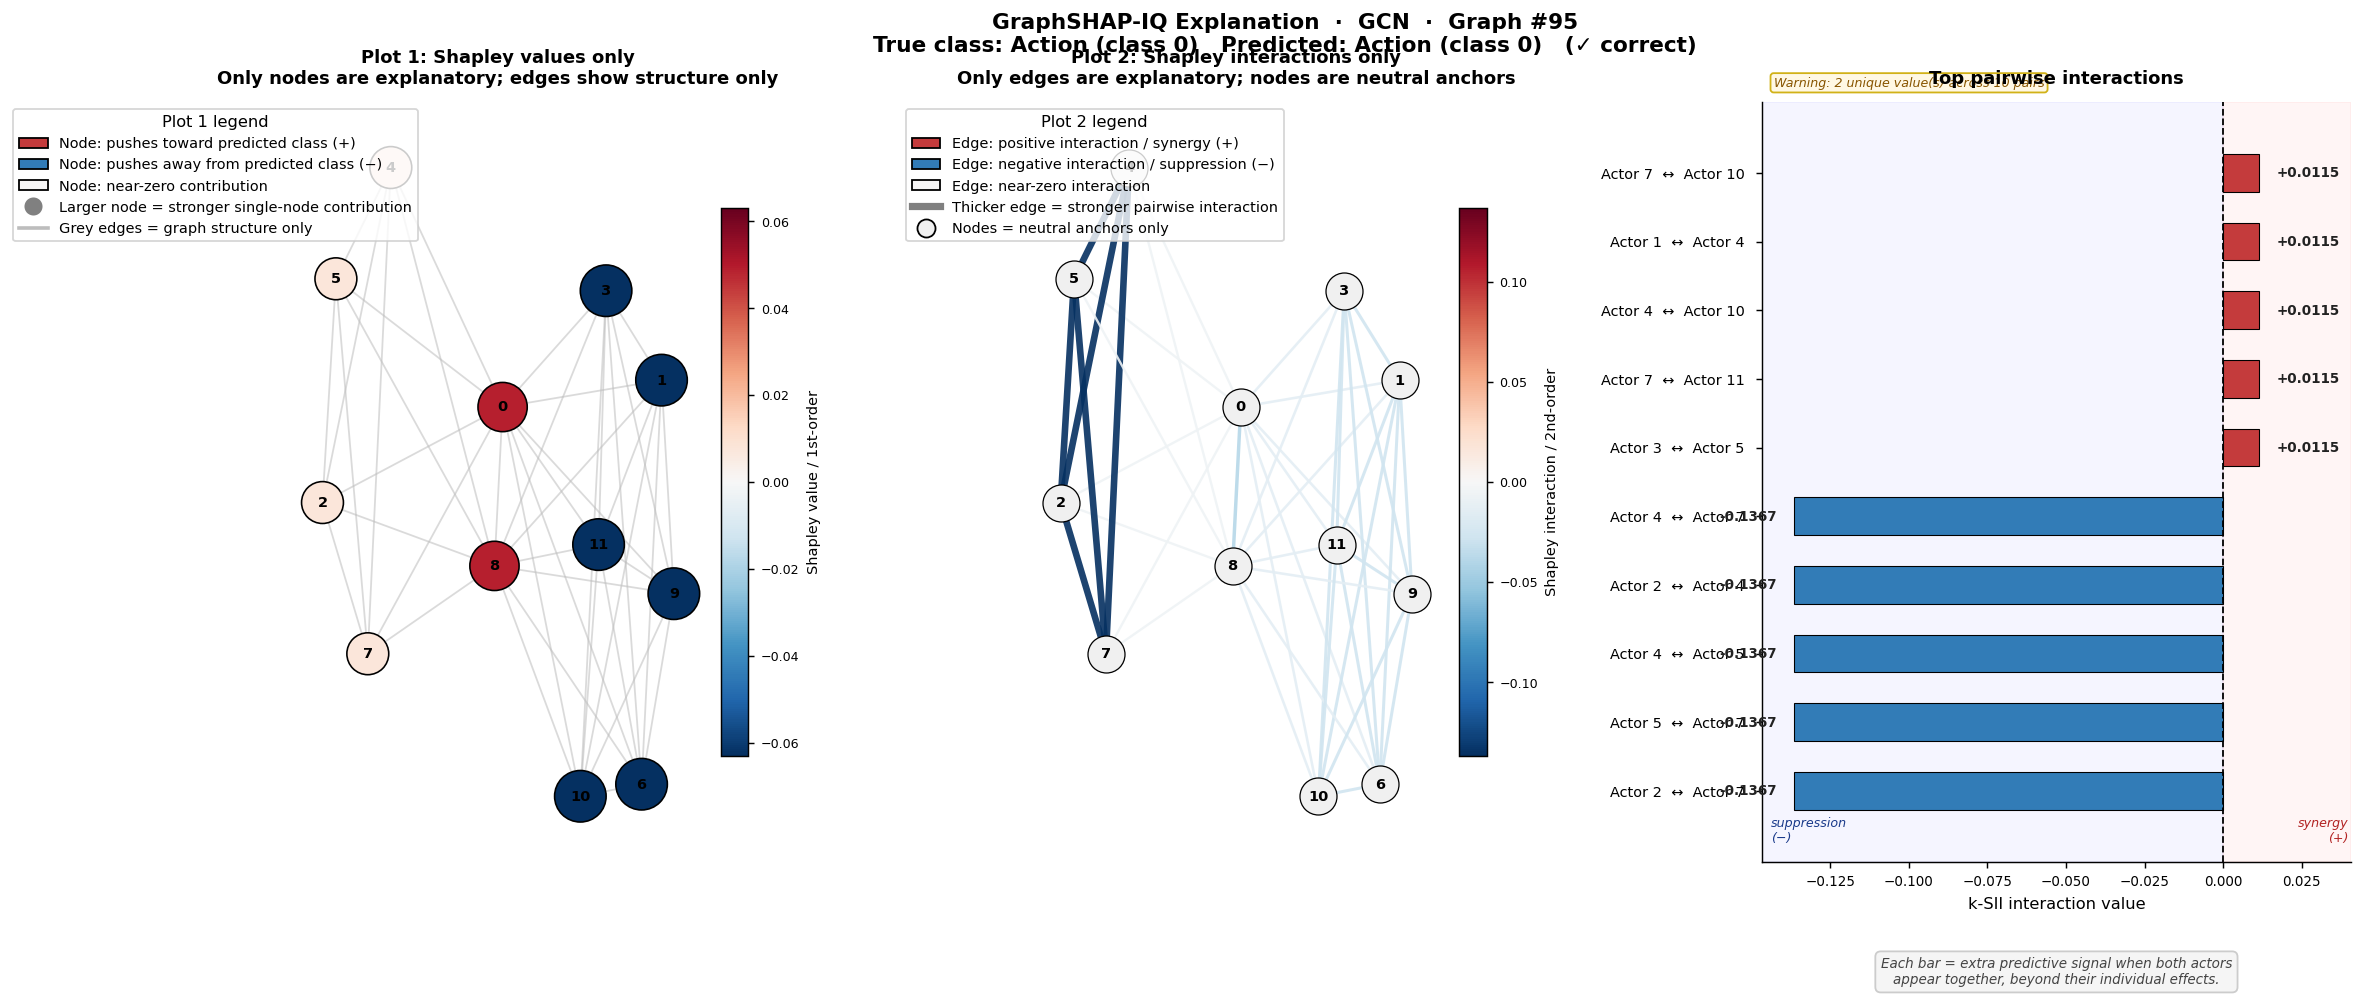

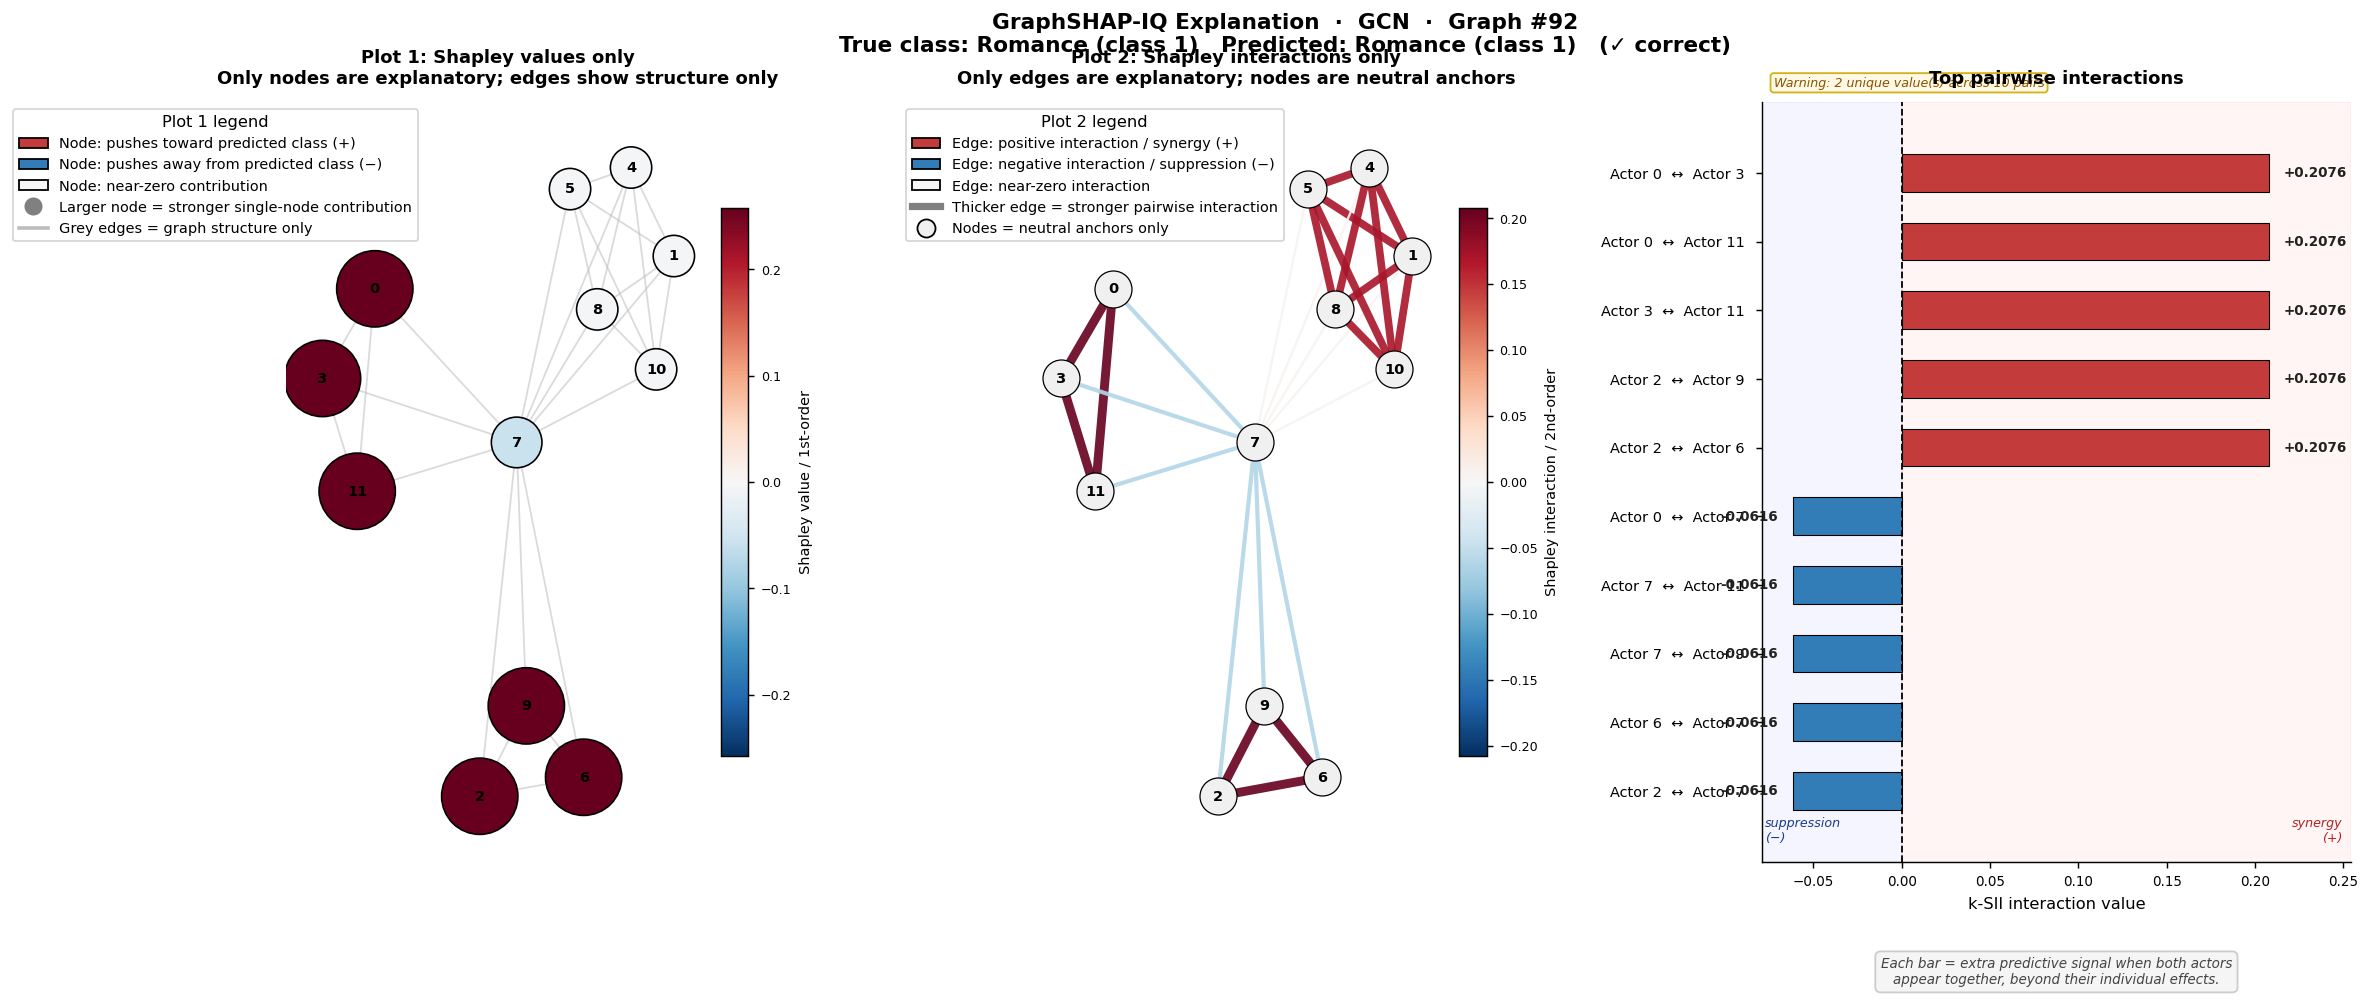

/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_69634/3023100215.py:658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.87])


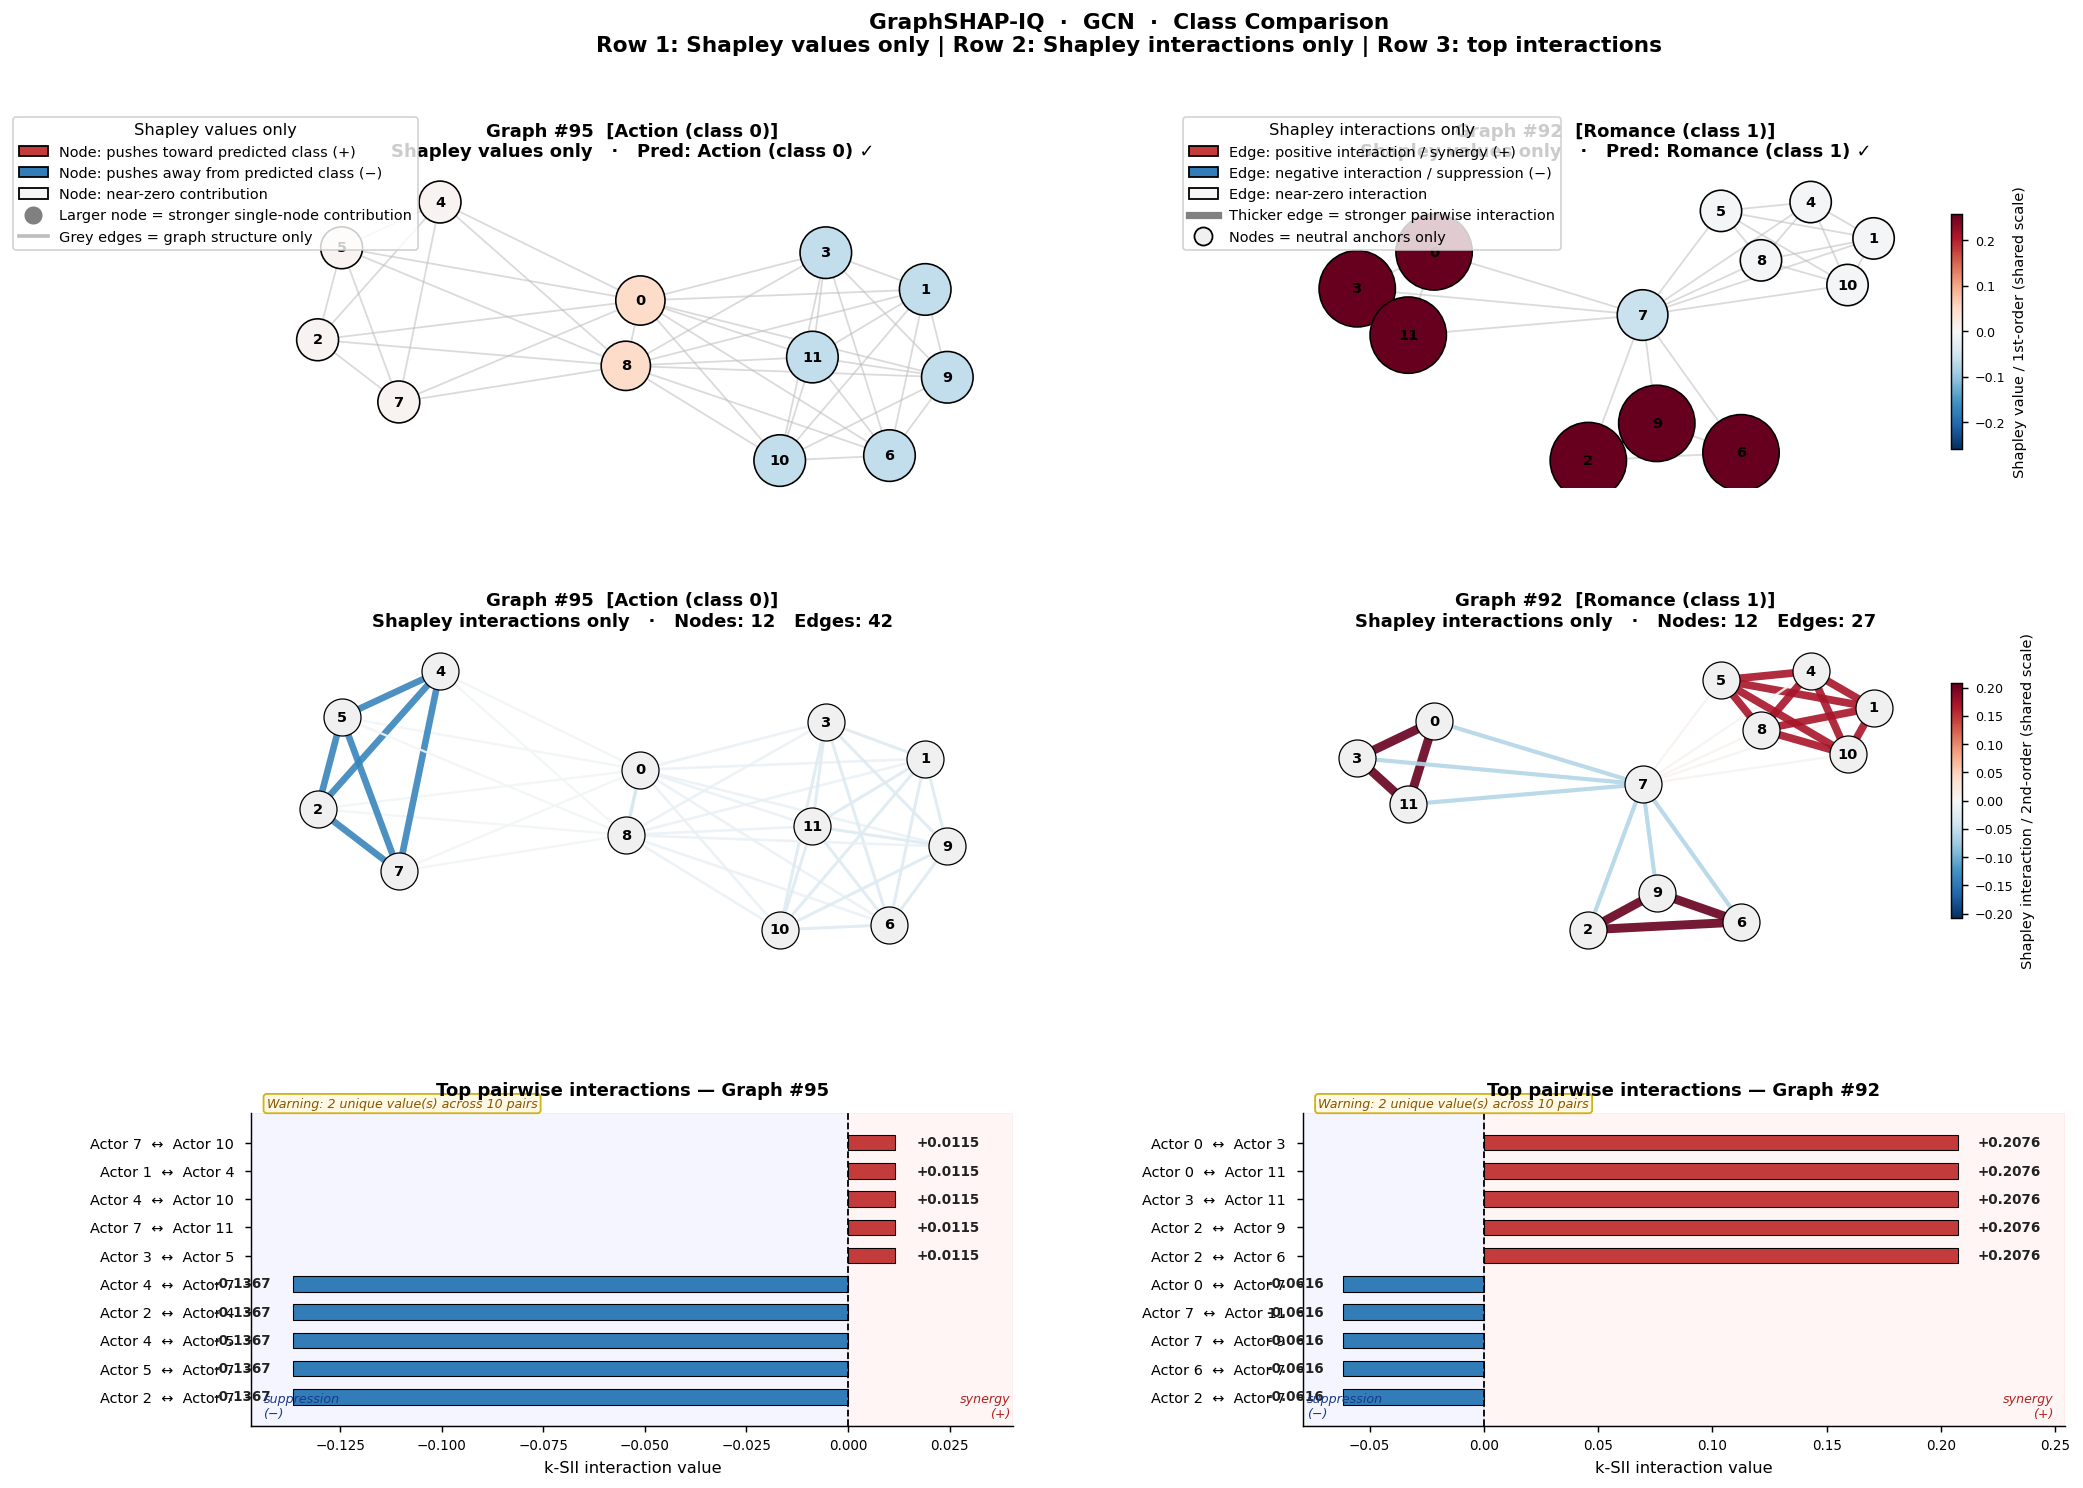

In [10]:
"""
GraphSHAP-IQ Visualization Module — IMDB-Binary Dataset
========================================================
Provides self-contained, publication-quality plots for explaining
graph classification results via k-SII interaction values.

Functions
---------
plot_single_graph_explanation  — explanation for one graph:
                                 (1) Shapley values only,
                                 (2) Shapley interactions only,
                                 (3) pairwise interaction bar chart
plot_first_order_graph         — node-only plot (single-node contributions)
plot_second_order_graph        — edge-only plot (pairwise interactions)
plot_class_comparison          — side-by-side pair (class 0 vs class 1)
plot_top_interactions_barchart — ranked bar chart of pairwise interactions
plot_comprehensive_analysis    — runs all pairs from explanation_results
"""

import warnings
import networkx as nx
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from torch_geometric.utils import to_networkx


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

_CMAP = plt.cm.RdBu_r
_CLASS_LABELS = {0: "Action (class 0)", 1: "Romance (class 1)"}


def _get_result(model_name: str, graph_idx: int, results_dict: dict) -> dict | None:
    for res in results_dict.get(model_name, []):
        if res["graph_idx"] == graph_idx:
            return res
    return None


def _build_networkx(pyg_graph):
    return to_networkx(pyg_graph, to_undirected=True)


def _node_draw_arrays(G: nx.Graph, node_scores: dict):
    base_size = 500
    score_scale = 5000
    sizes = [base_size + abs(node_scores.get(n, 0.0)) * score_scale for n in G.nodes()]
    colors = [node_scores.get(n, 0.0) for n in G.nodes()]
    return sizes, colors


def _edge_draw_arrays(G: nx.Graph, edge_scores: dict):
    edges = list(G.edges())
    base_width = 1.2
    score_scale = 18
    colors = [edge_scores.get(tuple(sorted((int(u), int(v)))), 0.0) for u, v in edges]
    widths = [base_width + abs(c) * score_scale for c in colors]
    return edges, colors, widths


def _shared_norm(all_scores: list[float]) -> mpl.colors.Normalize:
    vmax = max(abs(v) for v in all_scores) if all_scores else 1.0
    if vmax == 0:
        vmax = 1.0
    return mpl.colors.Normalize(vmin=-vmax, vmax=vmax)


def _draw_first_order_on_ax(
    ax: plt.Axes,
    G: nx.Graph,
    pos: dict,
    node_scores: dict,
    norm: mpl.colors.Normalize,
    title: str,
    subtitle: str = "",
) -> mpl.cm.ScalarMappable:
    node_sizes, node_colors = _node_draw_arrays(G, node_scores)

    sm = mpl.cm.ScalarMappable(cmap=_CMAP, norm=norm)
    sm.set_array([])

    nx.draw_networkx_edges(
        G, pos,
        edge_color="#bdbdbd",
        width=1.0,
        alpha=0.55,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G, pos,
        node_color=[_CMAP(norm(c)) for c in node_colors],
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.9,
        ax=ax,
    )

    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10, fontweight="bold", pad=10)
    ax.axis("off")
    return sm


def _draw_second_order_on_ax(
    ax: plt.Axes,
    G: nx.Graph,
    pos: dict,
    edge_scores: dict,
    norm: mpl.colors.Normalize,
    title: str,
    subtitle: str = "",
) -> mpl.cm.ScalarMappable:
    edges, edge_colors, edge_widths = _edge_draw_arrays(G, edge_scores)

    sm = mpl.cm.ScalarMappable(cmap=_CMAP, norm=norm)
    sm.set_array([])

    nx.draw_networkx_nodes(
        G, pos,
        node_color="#f0f0f0",
        node_size=420,
        edgecolors="black",
        linewidths=0.7,
        ax=ax,
    )

    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

    if edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color=[_CMAP(norm(c)) for c in edge_colors],
            width=edge_widths,
            alpha=0.9,
            ax=ax,
        )

    ax.set_title(f"{title}\n{subtitle}", fontsize=10, fontweight="bold", pad=10)
    ax.axis("off")
    return sm


def _first_order_legend_handles():
    return [
        mpatches.Patch(
            facecolor=_CMAP(0.85),
            edgecolor="black",
            label="Node: pushes toward predicted class (+)",
        ),
        mpatches.Patch(
            facecolor=_CMAP(0.15),
            edgecolor="black",
            label="Node: pushes away from predicted class (−)",
        ),
        mpatches.Patch(
            facecolor=_CMAP(0.5),
            edgecolor="black",
            label="Node: near-zero contribution",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="grey",
            markersize=11,
            label="Larger node = stronger single-node contribution",
        ),
        Line2D(
            [0], [0],
            color="#bdbdbd",
            linewidth=2.0,
            label="Grey edges = graph structure only",
        ),
    ]


def _second_order_legend_handles():
    return [
        mpatches.Patch(
            facecolor=_CMAP(0.85),
            edgecolor="black",
            label="Edge: positive interaction / synergy (+)",
        ),
        mpatches.Patch(
            facecolor=_CMAP(0.15),
            edgecolor="black",
            label="Edge: negative interaction / suppression (−)",
        ),
        mpatches.Patch(
            facecolor=_CMAP(0.5),
            edgecolor="black",
            label="Edge: near-zero interaction",
        ),
        Line2D(
            [0], [0],
            color="grey",
            linewidth=4,
            label="Thicker edge = stronger pairwise interaction",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="#f0f0f0",
            markeredgecolor="black",
            markersize=10,
            label="Nodes = neutral anchors only",
        ),
    ]


def plot_first_order_graph(
    model_name: str,
    graph_idx: int,
    results_dict: dict,
) -> None:
    data = _get_result(model_name, graph_idx, results_dict)
    if data is None:
        warnings.warn(f"No explanation data found for model='{model_name}', graph_idx={graph_idx}.")
        return

    G = _build_networkx(data["graph"])
    pos = nx.spring_layout(G, seed=42)
    node_scores = data["node_scores"]
    true_class = int(data["graph"].y.item())
    pred_class = data.get("pred_class", "?")
    correct = "✓ correct" if pred_class == true_class else "✗ wrong"

    norm = _shared_norm(list(node_scores.values()))

    fig, ax = plt.subplots(figsize=(8.2, 6.2))
    fig.suptitle(
        f"Shapley values only  ·  {model_name}  ·  Graph #{graph_idx}\n"
        f"True class: {_CLASS_LABELS.get(true_class, true_class)}   "
        f"Predicted: {_CLASS_LABELS.get(pred_class, pred_class)}   ({correct})",
        fontsize=11,
        fontweight="bold",
        y=0.98,
    )

    sm = _draw_first_order_on_ax(
        ax, G, pos, node_scores, norm,
        title="Single-node contributions",
        subtitle="Edges are neutral structure only",
    )

    cbar = fig.colorbar(sm, ax=ax, shrink=0.76, pad=0.02)
    cbar.set_label("Shapley value / 1st-order value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.legend(
        handles=_first_order_legend_handles(),
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=8,
        frameon=True,
        title="How to read this plot",
        title_fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.show()


def plot_second_order_graph(
    model_name: str,
    graph_idx: int,
    results_dict: dict,
) -> None:
    data = _get_result(model_name, graph_idx, results_dict)
    if data is None:
        warnings.warn(f"No explanation data found for model='{model_name}', graph_idx={graph_idx}.")
        return

    G = _build_networkx(data["graph"])
    pos = nx.spring_layout(G, seed=42)
    edge_scores = data["edge_scores"]
    true_class = int(data["graph"].y.item())
    pred_class = data.get("pred_class", "?")
    correct = "✓ correct" if pred_class == true_class else "✗ wrong"

    norm = _shared_norm(list(edge_scores.values()))

    fig, ax = plt.subplots(figsize=(8.2, 6.2))
    fig.suptitle(
        f"Shapley interactions only  ·  {model_name}  ·  Graph #{graph_idx}\n"
        f"True class: {_CLASS_LABELS.get(true_class, true_class)}   "
        f"Predicted: {_CLASS_LABELS.get(pred_class, pred_class)}   ({correct})",
        fontsize=11,
        fontweight="bold",
        y=0.98,
    )

    sm = _draw_second_order_on_ax(
        ax, G, pos, edge_scores, norm,
        title="Pairwise interactions",
        subtitle="Nodes are neutral anchors only",
    )

    cbar = fig.colorbar(sm, ax=ax, shrink=0.76, pad=0.02)
    cbar.set_label("Shapley interaction / 2nd-order value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.legend(
        handles=_second_order_legend_handles(),
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=8,
        frameon=True,
        title="How to read this plot",
        title_fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.show()


def plot_single_graph_explanation(
    model_name: str,
    graph_idx: int,
    results_dict: dict,
) -> None:
    data = _get_result(model_name, graph_idx, results_dict)
    if data is None:
        warnings.warn(f"No explanation data found for model='{model_name}', graph_idx={graph_idx}.")
        return

    G = _build_networkx(data["graph"])
    pos = nx.spring_layout(G, seed=42)
    node_scores = data["node_scores"]
    edge_scores = data["edge_scores"]
    true_class = int(data["graph"].y.item())
    pred_class = data.get("pred_class", "?")
    correct = "✓ correct" if pred_class == true_class else "✗ wrong"

    node_norm = _shared_norm(list(node_scores.values()))
    edge_norm = _shared_norm(list(edge_scores.values()))

    fig = plt.figure(figsize=(20.5, 7.6))
    fig.suptitle(
        f"GraphSHAP-IQ Explanation  ·  {model_name}  ·  Graph #{graph_idx}\n"
        f"True class: {_CLASS_LABELS.get(true_class, true_class)}   "
        f"Predicted: {_CLASS_LABELS.get(pred_class, pred_class)}   ({correct})",
        fontsize=12,
        fontweight="bold",
        y=0.97,
    )
    gs = gridspec.GridSpec(1, 3, width_ratios=[1.0, 1.0, 1.15], figure=fig, wspace=0.42)

    ax_first = fig.add_subplot(gs[0])
    ax_second = fig.add_subplot(gs[1])
    ax_bar = fig.add_subplot(gs[2])

    sm1 = _draw_first_order_on_ax(
        ax_first,
        G,
        pos,
        node_scores,
        node_norm,
        title="Plot 1: Shapley values only",
        subtitle="Only nodes are explanatory; edges show structure only",
    )

    sm2 = _draw_second_order_on_ax(
        ax_second,
        G,
        pos,
        edge_scores,
        edge_norm,
        title="Plot 2: Shapley interactions only",
        subtitle="Only edges are explanatory; nodes are neutral anchors",
    )

    cbar1 = fig.colorbar(sm1, ax=ax_first, shrink=0.72, pad=0.02)
    cbar1.set_label("Shapley value / 1st-order", fontsize=8)
    cbar1.ax.tick_params(labelsize=7)

    cbar2 = fig.colorbar(sm2, ax=ax_second, shrink=0.72, pad=0.02)
    cbar2.set_label("Shapley interaction / 2nd-order", fontsize=8)
    cbar2.ax.tick_params(labelsize=7)

    _draw_interaction_bars(
        ax_bar,
        data,
        top_k=5,
        title="Top pairwise interactions",
    )

    ax_bar.text(
        0.5,
        -0.16,
        "Each bar = extra predictive signal when both actors\n"
        "appear together, beyond their individual effects.",
        transform=ax_bar.transAxes,
        ha="center",
        fontsize=7.5,
        style="italic",
        color="#444444",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", edgecolor="#cccccc"),
    )

    fig.legend(
        handles=_first_order_legend_handles(),
        loc="upper left",
        bbox_to_anchor=(0.02, 0.88),
        fontsize=8,
        frameon=True,
        title="Plot 1 legend",
        title_fontsize=9,
    )

    fig.legend(
        handles=_second_order_legend_handles(),
        loc="upper left",
        bbox_to_anchor=(0.355, 0.88),
        fontsize=8,
        frameon=True,
        title="Plot 2 legend",
        title_fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.84])
    plt.show()


def _draw_interaction_bars(
    ax: plt.Axes,
    data: dict,
    top_k: int = 5,
    title: str = "",
) -> None:
    pos_pairs = data.get("top_positive", [])[:top_k]
    neg_pairs = data.get("top_negative", [])[:top_k]
    combined = sorted(pos_pairs + neg_pairs, key=lambda x: x[1])

    if not combined:
        ax.text(0.5, 0.5, "No interaction data available.",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
        return

    all_vals = [v for _, v in combined]
    n_unique = len(set(round(v, 6) for v in all_vals))
    ties_exist = n_unique < len(all_vals)

    labels = [f"Actor {p[0]}  ↔  Actor {p[1]}" for p, _ in combined]
    values = [v for _, v in combined]
    colors = [_CMAP(0.15) if v < 0 else _CMAP(0.85) for v in values]

    bars = ax.barh(
        labels,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
        height=0.55,
    )

    ax.axvline(0, color="black", linewidth=1, linestyle="--", zorder=3)

    x_range = max(abs(v) for v in values) if values else 1.0
    pad = x_range * 0.04 if x_range > 0 else 0.04

    for bar, val in zip(bars, values):
        if val >= 0:
            x_pos = bar.get_width() + pad
            ha = "left"
        else:
            x_pos = bar.get_width() - pad
            ha = "right"
        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.4f}",
            va="center",
            ha=ha,
            fontsize=7.5,
            fontweight="bold",
            color="#222222",
        )

    ax.set_xlabel("k-SII interaction value", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=10)
    ax.tick_params(axis="y", labelsize=8, pad=6)
    ax.tick_params(axis="x", labelsize=7.5)
    ax.margins(y=0.08)

    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin - pad * 0.5, xmax + pad * 4.0)

    xmin2, xmax2 = ax.get_xlim()
    ax.axvspan(0, xmax2, alpha=0.04, color="red", zorder=0)
    ax.axvspan(xmin2, 0, alpha=0.04, color="blue", zorder=0)

    ymin_data, _ = ax.get_ylim()
    ax.text(
        xmax2 * 0.98,
        ymin_data + 0.3,
        "synergy\n(+)",
        ha="right",
        fontsize=7,
        color="#b22222",
        style="italic",
        zorder=5,
    )
    ax.text(
        xmin2 * 0.98,
        ymin_data + 0.3,
        "suppression\n(−)",
        ha="left",
        fontsize=7,
        color="#1a3a8a",
        style="italic",
        zorder=5,
    )

    if ties_exist:
        ax.text(
            0.02,
            1.02,
            f"Warning: {n_unique} unique value(s) across {len(all_vals)} pairs",
            transform=ax.transAxes,
            ha="left",
            fontsize=7,
            color="#885500",
            style="italic",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#fff8e1",
                edgecolor="#ccaa00",
                alpha=0.9,
            ),
        )


def plot_top_interactions_barchart(
    model_name: str,
    graph_idx: int,
    results_dict: dict,
    top_k: int = 5,
    ax: plt.Axes | None = None,
) -> None:
    data = _get_result(model_name, graph_idx, results_dict)
    if data is None:
        warnings.warn(f"No data for model='{model_name}', graph_idx={graph_idx}.")
        return

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10.5, 4.8))
        true_class = int(data["graph"].y.item())
        fig.suptitle(
            f"Pairwise k-SII interactions  ·  {model_name}  ·  "
            f"Graph #{graph_idx}  [{_CLASS_LABELS.get(true_class, true_class)}]",
            fontsize=11,
            fontweight="bold",
        )

    _draw_interaction_bars(ax, data, top_k=top_k, title=f"Top {top_k} interactions — Graph #{graph_idx}")

    if standalone:
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()


def plot_class_comparison(
    model_name: str,
    graph_idx_0: int,
    graph_idx_1: int,
    results_dict: dict,
) -> None:
    data0 = _get_result(model_name, graph_idx_0, results_dict)
    data1 = _get_result(model_name, graph_idx_1, results_dict)

    if data0 is None or data1 is None:
        warnings.warn("Could not find one or both requested graph results.")
        return

    node_norm = _shared_norm(list(data0["node_scores"].values()) + list(data1["node_scores"].values()))
    edge_norm = _shared_norm(list(data0["edge_scores"].values()) + list(data1["edge_scores"].values()))

    fig = plt.figure(figsize=(18, 12.5))
    fig.suptitle(
        f"GraphSHAP-IQ  ·  {model_name}  ·  Class Comparison\n"
        "Row 1: Shapley values only | Row 2: Shapley interactions only | Row 3: top interactions",
        fontsize=12,
        fontweight="bold",
        y=0.98,
    )
    outer = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.38)

    for col, (data, idx) in enumerate([(data0, graph_idx_0), (data1, graph_idx_1)]):
        true_class = int(data["graph"].y.item())
        pred_class = data.get("pred_class", "?")
        correct = "✓" if pred_class == true_class else "✗"

        G = _build_networkx(data["graph"])
        pos = nx.spring_layout(G, seed=42)

        ax_first = fig.add_subplot(outer[0, col])
        sm1 = _draw_first_order_on_ax(
            ax_first, G, pos, data["node_scores"], node_norm,
            title=f"Graph #{idx}  [{_CLASS_LABELS.get(true_class, true_class)}]",
            subtitle=f"Shapley values only   ·   Pred: {_CLASS_LABELS.get(pred_class, pred_class)} {correct}",
        )

        ax_second = fig.add_subplot(outer[1, col])
        sm2 = _draw_second_order_on_ax(
            ax_second, G, pos, data["edge_scores"], edge_norm,
            title=f"Graph #{idx}  [{_CLASS_LABELS.get(true_class, true_class)}]",
            subtitle=f"Shapley interactions only   ·   Nodes: {G.number_of_nodes()}   Edges: {G.number_of_edges()}",
        )

        ax_bar = fig.add_subplot(outer[2, col])
        _draw_interaction_bars(ax_bar, data, top_k=5, title=f"Top pairwise interactions — Graph #{idx}")

        if col == 1:
            cbar1 = fig.colorbar(sm1, ax=ax_first, shrink=0.75, pad=0.03)
            cbar1.set_label("Shapley value / 1st-order (shared scale)", fontsize=8)
            cbar1.ax.tick_params(labelsize=7)

            cbar2 = fig.colorbar(sm2, ax=ax_second, shrink=0.75, pad=0.03)
            cbar2.set_label("Shapley interaction / 2nd-order (shared scale)", fontsize=8)
            cbar2.ax.tick_params(labelsize=7)

    fig.legend(
        handles=_first_order_legend_handles(),
        loc="upper left",
        bbox_to_anchor=(0.02, 0.92),
        fontsize=8,
        frameon=True,
        title="Shapley values only",
        title_fontsize=9,
    )

    fig.legend(
        handles=_second_order_legend_handles(),
        loc="upper left",
        bbox_to_anchor=(0.52, 0.92),
        fontsize=8,
        frameon=True,
        title="Shapley interactions only",
        title_fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.87])
    plt.show()


def plot_comprehensive_analysis(
    model_name: str,
    results_dict: dict,
) -> None:
    res_class_0 = [r for r in results_dict.get(model_name, []) if int(r["graph"].y.item()) == 0]
    res_class_1 = [r for r in results_dict.get(model_name, []) if int(r["graph"].y.item()) == 1]

    n_pairs = min(len(res_class_0), len(res_class_1))
    if n_pairs == 0:
        print("No complete pairs (class 0 + class 1) found — nothing to plot.")
        return

    print(f"GraphSHAP-IQ  ·  {model_name}  ·  {n_pairs} pair(s) to visualise\n")
    print(
        "  Plot 1 → Shapley values only: node color/size = single-node contribution\n"
        "  Plot 2 → Shapley interactions only: edge color/width = pairwise interaction\n"
        "  Plot 3 → strongest positive/negative pair interactions as bars\n"
    )

    for i, (g0, g1) in enumerate(zip(res_class_0, res_class_1)):
        sep = "─" * 60
        print(f"\n{sep}")
        print(f"  PAIR {i + 1}/{n_pairs}")
        print(f"    Graph #{g0['graph_idx']}  →  Action (class 0)  | Nodes: {g0['graph'].num_nodes}")
        print(f"    Graph #{g1['graph_idx']}  →  Romance (class 1) | Nodes: {g1['graph'].num_nodes}")
        print(f"{sep}\n")

        plot_single_graph_explanation(model_name, g0["graph_idx"], results_dict)
        plot_single_graph_explanation(model_name, g1["graph_idx"], results_dict)
        plot_class_comparison(model_name, g0["graph_idx"], g1["graph_idx"], results_dict)


if __name__ == "__main__" or "explanation_results" in dir():
    try:
        if explanation_results:
            chosen_model = list(explanation_results.keys())[0]
            plot_comprehensive_analysis(
                model_name=chosen_model,
                results_dict=explanation_results,
            )
    except NameError:
        print("Paste your `explanation_results` dict and run again.")